# 06 · Predictive (Supervised) Analytics
**Process-model step:** *Analyse the data — predictive* (Fraud Analytics ch. 4) · **AML concept:** scoring alerts / customers, reducing false positives · **Statistics (*Practical Statistics* ch. 4–6):** logistic regression & odds ratios, trees, bagging/random forests, boosting, cross-validation, imbalanced data, ROC / precision-recall / lift, calibration

Two use cases, because the *label* behaves very differently:

| | **A · Card-not-present fraud (transaction level)** | **B · AML customer risk (customer level)** |
|---|---|---|
| Label quality | good (chargebacks) | **biased** (STR exists only for alerted customers) |
| Main risks | class imbalance, leakage in time, cost-based threshold | selection bias / reject inference, base rate |
| Evaluation | out-of-time, cost curve | must include *non-alerted* customers |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib, warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.inspection import permutation_importance
import amlkit as ak

pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
(ak.ROOT / "models").mkdir(exist_ok=True)
txn = pd.read_pickle(ak.PROC / "txn_clean.pkl"); kyc = pd.read_pickle(ak.PROC / "kyc_clean.pkl")

# Part A · Payment fraud model (transaction level)
## A1 · Target definition and feature engineering (no look-ahead!)
Target = `is_fraud`. Features may only use information **available at decision time**: the transaction itself plus the customer's *past*. Anything computed with future rows is leakage and will vanish in production. Fraud Analytics ch. 2 calls the behavioural aggregates (recency / frequency / monetary, velocity) the most valuable inputs.

In [2]:
c = txn[txn.channel == "card_online"].sort_values(["customer_id", "ts"]).reset_index(drop=True)
c["log_amt"] = np.log(c.amount_usd)
g = c.groupby("customer_id"); k = g.cumcount()
s1 = g["log_amt"].cumsum() - c.log_amt                                   # sums over PREVIOUS rows only
s2 = (c.log_amt ** 2).groupby(c.customer_id).cumsum() - c.log_amt ** 2
mu_prev = s1 / k.replace(0, np.nan); var_prev = (s2 / k.replace(0, np.nan) - mu_prev ** 2).clip(lower=0)
c["amt_z"] = ((c.log_amt - mu_prev) / np.sqrt(var_prev + 0.25)).fillna(0)     # amount vs customer's own history
c["log_hrs_since_prev"] = np.log1p(g.ts.diff().dt.total_seconds().div(3600).fillna(999).clip(upper=999))
tmp = c.set_index("ts")
for w in ("1h", "24h"):
    c[f"n_prev_{w}"] = tmp.groupby("customer_id")["amount_usd"].rolling(w, closed="left").count().fillna(0).values   # closed='left' excludes the current txn
c["night"] = c.hour.isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
c["foreign"] = (c.country != "KH").astype(int)

F_TXN = ["log_amt", "hour", "night", "foreign", "new_device"]
F_BEH = ["amt_z", "log_hrs_since_prev", "n_prev_1h", "n_prev_24h"]
F_ALL = F_TXN + F_BEH
print(f"{len(c):,} card-online transactions | fraud rate {c.is_fraud.mean():.3%} | {c.is_fraud.sum()} frauds")
c.groupby("is_fraud")[F_ALL].median().T

84,463 card-online transactions | fraud rate 0.453% | 383 frauds


is_fraud,0,1
log_amt,4.333,4.995
hour,12.000,10.000
night,0.000,0.000
foreign,0.000,1.000
new_device,0.000,1.000
amt_z,0.000,0.446
log_hrs_since_prev,5.207,0.189
n_prev_1h,0.000,1.000
n_prev_24h,0.000,1.000


## A2 · Split by **time**, not at random
Fraud evolves and bursts cluster in time and customers. Train on the past (Jan–Sep), test on the future (Oct–Dec) — this is the *out-of-time* test the book recommends.

In [3]:
CUT = 255
train, test = c[c.day < CUT], c[c.day >= CUT]
print(f"train {len(train):,} ({train.is_fraud.sum()} fraud) | test {len(test):,} ({test.is_fraud.sum()} fraud)")

def score_report(name, y, p, k_share=0.01):
    o = np.argsort(-p); k = int(k_share * len(y)); top = y[o[:k]]
    return dict(model=name, AUC=roc_auc_score(y, p), avg_precision=average_precision_score(y, p),
                **{f"precision@{k_share:.0%}": top.mean(), f"recall@{k_share:.0%}": top.sum() / y.sum()})

train 59,029 (243 fraud) | test 25,434 (140 fraud)


## A3 · Model zoo (logistic → tree → forest → boosting), with and without behavioural features

In [4]:
models = {
    "Logistic (txn features only)": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), F_TXN),
    "Logistic (+behavioural)":      (make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), F_ALL),
    "Decision tree (depth 5)":      (DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=0), F_ALL),
    "Random forest":                (RandomForestClassifier(300, min_samples_leaf=5, n_jobs=-1, random_state=0), F_ALL),
    "Gradient boosting (unregularised)": (HistGradientBoostingClassifier(max_depth=4, learning_rate=0.1, max_iter=200, random_state=0), F_ALL),
    "Gradient boosting (regularised)":   (HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=150, min_samples_leaf=100,
                                                                        l2_regularization=5.0, random_state=0), F_ALL),
}
fitted, preds, rows = {}, {}, []
for name, (m, cols) in models.items():
    m.fit(train[cols], train.is_fraud); fitted[name] = (m, cols)
    preds[name] = m.predict_proba(test[cols])[:, 1]
    rows.append(score_report(name, test.is_fraud.values, preds[name]))
comp = pd.DataFrame(rows).set_index("model"); comp

,AUC,avg_precision,precision@1%,recall@1%
model,,,,
Logistic (txn features only),0.915,0.299,0.268,0.486
Logistic (+behavioural),0.946,0.711,0.398,0.721
Decision tree (depth 5),0.905,0.629,0.394,0.714
Random forest,0.930,0.704,0.406,0.736
Gradient boosting (unregularised),0.803,0.492,0.327,0.593
Gradient boosting (regularised),0.948,0.715,0.409,0.743


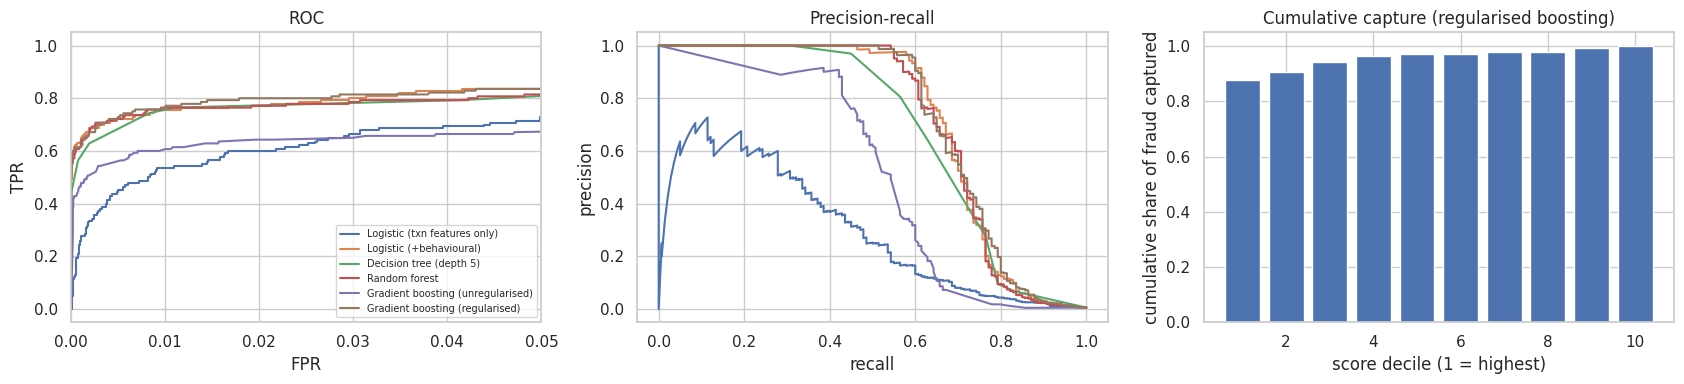

,n,frauds,rate,lift,cum_capture
decile,,,,,
1,2544,123,0.048,8.784,0.879
2,2543,4,0.002,0.286,0.907
3,2543,5,0.002,0.357,0.943
4,2544,3,0.001,0.214,0.964
5,2543,1,0.000,0.071,0.971
6,2543,0,0.000,0.000,0.971
7,2544,1,0.000,0.071,0.979
8,2543,0,0.000,0.000,0.979
9,2543,2,0.001,0.143,0.993


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for name, p in preds.items():
    fpr, tpr, _ = roc_curve(test.is_fraud, p); ax[0].plot(fpr, tpr, label=name)
    pr, rc, _ = precision_recall_curve(test.is_fraud, p); ax[1].plot(rc, pr, label=name)
ax[0].set(xlabel="FPR", ylabel="TPR", title="ROC", xlim=(0, .05)); ax[1].set(xlabel="recall", ylabel="precision", title="Precision-recall"); ax[0].legend(fontsize=7)
lt = ak.lift_table(test.is_fraud.values, preds["Gradient boosting (regularised)"])
ax[2].bar(lt.index, lt.cum_capture); ax[2].set(xlabel="score decile (1 = highest)", ylabel="cumulative share of fraud captured", title="Cumulative capture (regularised boosting)")
plt.tight_layout(); plt.show()
lt

Adding **behavioural features** (customer history, velocity) matters more than the choice of algorithm. Note the *unregularised* boosting model **overfits** the ≈ 240 training frauds (AUC ≈ 0.80): with rare positives, regularisation (`min_samples_leaf`, `l2_regularization`, small learning rate) is the key hyper-parameter lever (*Practical Statistics* ch. 6). The lab's fraud is simpler than most real fraud, so treat the absolute scores as illustrative — the *process* is what transfers.

### Interpretation (*Practical Statistics* ch. 5: odds ratios) and reason codes

In [6]:
lr, cols = fitted["Logistic (+behavioural)"]
coef = pd.Series(lr[-1].coef_[0], index=cols)
odds = pd.DataFrame({"coef (per 1 SD)": coef, "odds ratio (per 1 SD)": np.exp(coef)}).sort_values("coef (per 1 SD)", ascending=False); odds

,coef (per 1 SD),odds ratio (per 1 SD)
foreign,0.830,2.294
new_device,0.730,2.076
n_prev_1h,0.560,1.751
night,0.460,1.584
log_amt,0.437,1.548
n_prev_24h,0.381,1.464
amt_z,0.224,1.251
log_hrs_since_prev,-0.154,0.857
hour,-0.185,0.831


In [7]:
def reason_codes(model_pipe, cols, X, top=3):
    '''Top positive contributions (coef x standardised value) per row = analyst-facing reason codes.'''
    sc, lg = model_pipe[0], model_pipe[-1]
    contrib = sc.transform(X[cols]) * lg.coef_[0]
    order = np.argsort(-contrib, axis=1)[:, :top]
    return [[cols[j] for j in row if contrib[i, j] > 0] for i, row in enumerate(order)]

top_alerts = test.assign(p=preds["Logistic (+behavioural)"]).nlargest(5, "p")
top_alerts[["customer_id", "amount_usd", "hour", "country", "p", "is_fraud"]].assign(reasons=reason_codes(lr, cols, top_alerts))

,customer_id,amount_usd,hour,country,p,is_fraud,reasons
2188,99,91.800,18,CN,1.000,1,"[n_prev_1h, n_prev_24h, new_device]"
54056,2218,86.610,17,US,1.000,1,"[n_prev_1h, n_prev_24h, new_device]"
29096,1212,94.200,4,KH,1.000,1,"[n_prev_1h, n_prev_24h, new_device]"
21001,901,79.820,4,KH,1.000,1,"[n_prev_1h, n_prev_24h, new_device]"
10125,422,129.940,0,HK,1.000,1,"[n_prev_1h, n_prev_24h, new_device]"


Non-linear model importance (permutation importance on the test period — model-agnostic, works for boosting):

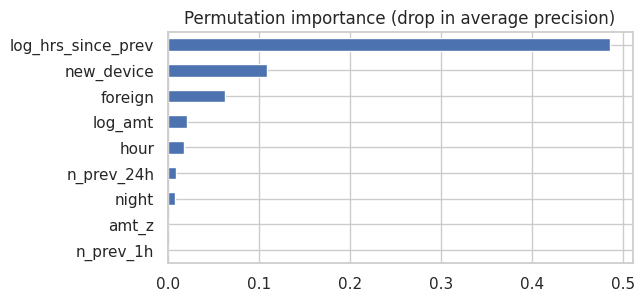

In [8]:
m_h, cols_h = fitted["Gradient boosting (regularised)"]
pi = permutation_importance(m_h, test[cols_h].iloc[:20000], test.is_fraud.iloc[:20000], scoring="average_precision", n_repeats=5, random_state=0, n_jobs=-1)
pd.Series(pi.importances_mean, index=cols_h).sort_values().plot.barh(figsize=(6, 3)); plt.title("Permutation importance (drop in average precision)"); plt.show()

## A4 · Does the validation scheme matter? (leakage)
Random K-fold puts bursts of the *same* customer in both train and validation folds. Compare with **customer-grouped** folds and with the out-of-time test:

In [9]:
Xtr, ytr, grp = train[F_ALL], train.is_fraud, train.customer_id
rf = RandomForestClassifier(200, min_samples_leaf=3, n_jobs=-1, random_state=0)
random_cv = cross_val_score(rf, Xtr, ytr, cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="average_precision")
group_cv  = cross_val_score(rf, Xtr, ytr, cv=StratifiedGroupKFold(5, shuffle=True, random_state=0), groups=grp, scoring="average_precision")
oot = average_precision_score(test.is_fraud, rf.fit(Xtr, ytr).predict_proba(test[F_ALL])[:, 1])
print(f"average precision  random 5-fold {random_cv.mean():.3f} ± {random_cv.std():.3f} | grouped-by-customer {group_cv.mean():.3f} ± {group_cv.std():.3f} | out-of-time test {oot:.3f}")

average precision  random 5-fold 0.696 ± 0.090 | grouped-by-customer 0.700 ± 0.092 | out-of-time test 0.702


The gap can be small on this easy lab problem and **large** when customer-specific identifiers or slow-moving features are present. Default to grouped / out-of-time validation for fraud.

## A5 · Class imbalance strategies (*Practical Statistics* ch. 5)
Compare: nothing · class weights · under-sampling · over-sampling. Watch **calibration**, not just ranking: re-balancing distorts predicted probabilities.

In [10]:
rng = np.random.default_rng(0)
pos, neg = np.flatnonzero(train.is_fraud.values == 1), np.flatnonzero(train.is_fraud.values == 0)
def make(kind):
    if kind == "under (1:10)": idx = np.r_[pos, rng.choice(neg, 10 * len(pos), replace=False)]
    elif kind == "over (x20)": idx = np.r_[neg, rng.choice(pos, 20 * len(pos), replace=True)]
    else: idx = np.r_[pos, neg]
    return train.iloc[idx]
rows = []
for kind, cw in [("none", None), ("class weights", "balanced"), ("under (1:10)", None), ("over (x20)", None)]:
    d = make(kind if kind in ("under (1:10)", "over (x20)") else "none")
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight=cw)).fit(d[F_ALL], d.is_fraud)
    p = m.predict_proba(test[F_ALL])[:, 1]
    r = score_report(kind, test.is_fraud.values, p); r["mean predicted p"] = p.mean(); r["true fraud rate"] = test.is_fraud.mean(); rows.append(r)
pd.DataFrame(rows).set_index("model")

,AUC,avg_precision,precision@1%,recall@1%,mean predicted p,true fraud rate
model,,,,,,
none,0.946,0.711,0.398,0.721,0.005,0.006
class weights,0.947,0.693,0.394,0.714,0.130,0.006
under (1:10),0.946,0.707,0.398,0.721,0.030,0.006
over (x20),0.947,0.707,0.402,0.729,0.026,0.006


Ranking metrics barely change, but **mean predicted probability** inflates a lot for re-balanced training (class weights ≈ 25× the true rate, resampling ≈ 5×). If probabilities feed expected-loss maths or a calibration back-test (notebook 08), *re-calibrate* (isotonic / Platt / prior-correction) on an untouched sample.

## A6 · Choose the operating threshold with **costs**
Net benefit = value of fraud stopped − friction cost of challenging genuine customers. (Amounts differ, so use the transaction amount, not a count.)

optimal threshold p >= 0.0180: challenge 1.92% of card-online txns, catch 86.4% of fraud value, net benefit $23,905 (friction $3 per false alarm)


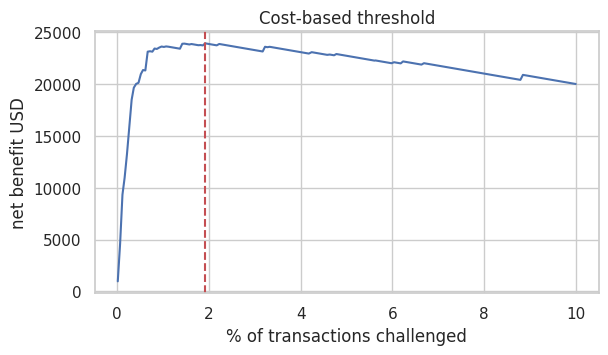

In [11]:
p = preds["Gradient boosting (regularised)"]; y = test.is_fraud.values; amt = test.amount_usd.values
C_FP = 3.0
ths = np.quantile(p, np.linspace(0.90, 0.9999, 200))
net = [(amt[(p >= t) & (y == 1)].sum() - C_FP * ((p >= t) & (y == 0)).sum()) for t in ths]
best = int(np.argmax(net)); t_star = ths[best]
chal = (p >= t_star).mean()
print(f"optimal threshold p >= {t_star:.4f}: challenge {chal:.2%} of card-online txns, catch {amt[(p>=t_star)&(y==1)].sum()/amt[y==1].sum():.1%} of fraud value, "
      f"net benefit ${max(net):,.0f} (friction ${C_FP:.0f} per false alarm)")
fig, ax = plt.subplots(figsize=(6.5, 3.4)); ax.plot([(p >= t).mean() * 100 for t in ths], net); ax.axvline(chal * 100, c="r", ls="--")
ax.set(xlabel="% of transactions challenged", ylabel="net benefit USD", title="Cost-based threshold"); plt.show()

## A7 · Calibration and save the champion / challenger
Reliability by score decile (predicted vs observed), then persist the models and the scored test set for notebook 08.

In [12]:
cal = pd.DataFrame({"p": preds["Logistic (+behavioural)"], "y": test.is_fraud.values})
cal["bin"] = pd.qcut(cal.p.rank(method="first"), 10, labels=False) + 1
cal.groupby("bin").agg(mean_predicted=("p", "mean"), observed_rate=("y", "mean"), n=("y", "size"), frauds=("y", "sum"))

,mean_predicted,observed_rate,n,frauds
bin,,,,
1,0.000,0.000,2544,0
2,0.000,0.001,2543,2
3,0.000,0.000,2543,1
4,0.000,0.000,2544,0
5,0.000,0.001,2543,2
6,0.000,0.000,2543,1
7,0.000,0.001,2544,3
8,0.001,0.002,2543,4
9,0.002,0.002,2543,6


In [13]:
champion, ch_cols = fitted["Logistic (+behavioural)"]; challenger, cg_cols = fitted["Gradient boosting (regularised)"]
joblib.dump(dict(model=champion, features=ch_cols, threshold=float(np.quantile(preds["Logistic (+behavioural)"], 0.99)), trained_until_day=CUT, name="fraud_champion_logit"),
            ak.ROOT / "models" / "fraud_champion.joblib")
joblib.dump(dict(model=challenger, features=cg_cols, threshold=float(t_star), trained_until_day=CUT, name="fraud_challenger_hgb"),
            ak.ROOT / "models" / "fraud_challenger.joblib")
scored = pd.concat([train.assign(split="train"), test.assign(split="test")])[["txn_id", "customer_id", "day", "ts", "amount_usd", "is_fraud", "split"] + F_ALL]
scored["p_champion"] = champion.predict_proba(scored[ch_cols])[:, 1]; scored["p_challenger"] = challenger.predict_proba(scored[cg_cols])[:, 1]
scored.to_pickle(ak.PROC / "fraud_scored.pkl"); print("saved models + scored transactions:", scored.shape)

saved models + scored transactions: (84463, 18)


---
# Part B · AML customer-risk model — the label-bias problem
We want to rank **customers** by laundering risk. Labels available in practice: *STR filed* — but only for customers the production scenario alerted. Compare three training sets, evaluated on a **held-out sample of all customers** (this evaluation is only possible in the lab, thanks to the oracle):

* **M1** – trained on alerted customers only (label = STR ever filed) → what most banks would do
* **M2** – M1 **plus a random sample of non-alerted customers** reviewed by investigators, re-weighted by the inverse of their sampling probability (*reject inference* via inverse-probability weighting)
* **M3** – oracle labels on all training customers (unattainable upper bound)

In [14]:
feat = pd.read_pickle(ak.PROC / "features.pkl"); truth = ak.load_truth()
prod = ak.simulate_dispositions(ak.run_scenario(txn, len(kyc)), truth)
feat["alerted"] = feat.customer_id.isin(prod.customer_id).astype(int)
feat["str_label"] = feat.customer_id.map(prod.groupby("customer_id").str_filed.max())
XB = ["log_turnover_ratio", "log_max_cash_agg_5d", "near_ctr_cnt", "flowthrough_max", "hr_share", "log_n_counterparties", "night_share",
      "cash_share_credits", "log_n_txn", "log_mean_amt", "log_credits", "log_amt_wire_in", "log_amt_cash_deposit"]

def rf(): return RandomForestClassifier(300, min_samples_leaf=3, class_weight="balanced_subsample", n_jobs=-1, random_state=0)

def experiment(seed, n_random=300):
    tr, te = train_test_split(feat, test_size=0.3, stratify=feat.is_launderer, random_state=seed)
    a = tr[tr.alerted == 1]; non = tr[tr.alerted == 0]; smp = non.sample(min(n_random, len(non)), random_state=seed)
    m1 = rf().fit(a[XB], a.str_label)
    m2 = rf().fit(pd.concat([a, smp])[XB], np.r_[a.str_label.values, smp.is_launderer.values],
                  sample_weight=np.r_[np.ones(len(a)), np.full(len(smp), len(non) / len(smp))])
    m3 = rf().fit(tr[XB], tr.is_launderer)
    out = {}
    na = te[te.alerted == 0]
    for nm, m in (("M1 alerted-only", m1), ("M2 + random sample (IPW)", m2), ("M3 oracle (upper bound)", m3)):
        p = m.predict_proba(te[XB])[:, 1]; o = np.argsort(-p); top = te.iloc[o[:int(.10 * len(te))]]
        out[nm] = dict(AUC_all=roc_auc_score(te.is_launderer, p), AP_all=average_precision_score(te.is_launderer, p),
                       recall_top10pct=top.is_launderer.sum() / te.is_launderer.sum(),
                       AUC_nonalerted=roc_auc_score(na.is_launderer, m.predict_proba(na[XB])[:, 1]))
    return pd.DataFrame(out).T

res = pd.concat([experiment(s) for s in range(12)]).groupby(level=0).agg(["mean", "std"])
res.loc[["M1 alerted-only", "M2 + random sample (IPW)", "M3 oracle (upper bound)"]]

AUC_all       AP_all       recall_top10pct        \
                            mean   std   mean   std            mean   std   
M1 alerted-only            0.633 0.053  0.470 0.068           0.475 0.074   
M2 + random sample (IPW)   0.951 0.014  0.642 0.061           0.791 0.050   
M3 oracle (upper bound)    0.970 0.014  0.740 0.074           0.851 0.079   

                         AUC_nonalerted        
                                   mean   std  
M1 alerted-only                   0.399 0.043  
M2 + random sample (IPW)          0.938 0.029  
M3 oracle (upper bound)           0.971 0.023

**M1's AUC on non-alerted customers is below 0.5**: trained only on alerted customers it learns patterns *inside* the selected region and ranks the unselected region badly — precisely where false negatives hide. A modest random labelled sample with inverse-probability weights (M2) recovers most of the oracle model's performance. How big must the random sample be?

In [15]:
rows = []
for n_r in (0, 50, 100, 300, 600):
    sub = []
    for s in range(8):
        tr, te = train_test_split(feat, test_size=0.3, stratify=feat.is_launderer, random_state=s)
        a = tr[tr.alerted == 1]; non = tr[tr.alerted == 0]
        if n_r == 0: m = rf().fit(a[XB], a.str_label)
        else:
            smp = non.sample(n_r, random_state=s)
            m = rf().fit(pd.concat([a, smp])[XB], np.r_[a.str_label.values, smp.is_launderer.values], sample_weight=np.r_[np.ones(len(a)), np.full(n_r, len(non) / n_r)])
        na = te[te.alerted == 0]; sub.append(roc_auc_score(na.is_launderer, m.predict_proba(na[XB])[:, 1]))
    rows.append(dict(random_labelled_sample=n_r, AUC_on_nonalerted=np.mean(sub), sd=np.std(sub)))
pd.DataFrame(rows).set_index("random_labelled_sample")

,AUC_on_nonalerted,sd
random_labelled_sample,,
0,0.399,0.044
50,0.917,0.034
100,0.923,0.026
300,0.945,0.020
600,0.957,0.025


Even ≈ 100 randomly selected, carefully reviewed non-alerted customers help a lot — a cheap and defensible investment compared with the cost of model risk.

### Final AML model & persistence
Fit M2-style on all customers (alerted STR labels + a random reviewed sample), score everyone and save for notebook 08.

In [16]:
non = feat[feat.alerted == 0]; smp = non.sample(300, random_state=0); a = feat[feat.alerted == 1]
aml_model = rf().fit(pd.concat([a, smp])[XB], np.r_[a.str_label.values, smp.is_launderer.values],
                     sample_weight=np.r_[np.ones(len(a)), np.full(len(smp), len(non) / len(smp))])
feat["aml_risk_score"] = aml_model.predict_proba(feat[XB])[:, 1]
joblib.dump(dict(model=aml_model, features=XB, name="aml_customer_rf_ipw"), ak.ROOT / "models" / "aml_customer_model.joblib")
feat[["customer_id", "segment", "aml_risk_score", "alerted", "is_launderer"] + XB].to_pickle(ak.PROC / "aml_scored.pkl")
print("top-100 risk scores contain", int(feat.nlargest(100, "aml_risk_score").is_launderer.sum()), "true suspicious customers (oracle) |",
      int(feat[feat.alerted == 0].nlargest(50, "aml_risk_score").is_launderer.sum()), "of the top-50 NON-alerted customers are suspicious")

top-100 risk scores contain 86 true suspicious customers (oracle) | 29 of the top-50 NON-alerted customers are suspicious


### Take-aways
1. Feature engineering with **history/velocity** beats swapping algorithms.
2. Validate **out-of-time / grouped**; tune the threshold with **costs**; check **calibration** if probabilities are used.
3. For AML labels, model the **selection mechanism**: random labelled sample + weights (reject inference).
4. Keep an interpretable champion (logistic + reason codes) beside a stronger challenger (boosting).

**Next → `07_social_network_analytics`**